In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [323]:
df = pd.read_csv('bayut_listings.csv')
scaler = MinMaxScaler()

df.head()

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
0,"1,650,000",Floor,5,4,523 Sq. M.,"Al Rayyan, East Riyadh, Riyadh"
1,"1,249,000",Floor,6,5,500 Sq. M.,"Al Khaleej, East Riyadh, Riyadh"
2,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"
3,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"
4,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"


In [324]:
df.describe()

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
count,14060,14060,14060,14060,14060,14060
unique,709,10,16,13,862,807
top,"750,000",Apartment,3,3,300 Sq. M.,"Al Mahdiyah, West Riyadh, Riyadh"
freq,393,7052,3538,5289,293,930


In [325]:
df['Property Type'].unique()
df2 = df[~df['Property Type'].str.contains(r'\d')]

df2 = df2[df2['Number Of Bedrooms'].str.contains(r'\d')]


In [326]:
df2['Property Type'].describe()

count         14040
unique            8
top       Apartment
freq           7034
Name: Property Type, dtype: object

In [327]:
df2.describe()

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
count,14040,14040,14040,14040,14040,14040
unique,707,8,13,11,860,806
top,"750,000",Apartment,3,3,300 Sq. M.,"Al Mahdiyah, West Riyadh, Riyadh"
freq,393,7034,3538,5280,293,930


In [328]:
df2['Area'] = df2['Area'].apply(lambda x: x.replace('Sq. M.',''))

In [329]:
df2.describe()

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
count,14040,14040,14040,14040,14040,14040
unique,707,8,13,11,860,806
top,"750,000",Apartment,3,3,300,"Al Mahdiyah, West Riyadh, Riyadh"
freq,393,7034,3538,5280,293,930


In [330]:
df2.head(10)

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
0,"1,650,000",Floor,5,4,523,"Al Rayyan, East Riyadh, Riyadh"
1,"1,249,000",Floor,6,5,500,"Al Khaleej, East Riyadh, Riyadh"
2,"499,000",Apartment,3,3,154,"Al Sakb, Madina"
3,"499,000",Apartment,3,3,154,"Al Sakb, Madina"
4,"499,000",Apartment,3,3,154,"Al Sakb, Madina"
5,"950,000",Apartment,6,5,220,"Al Rabwa, North Jeddah, Jeddah"
6,"560,000",Apartment,4,4,134,"Al Rabwa, North Jeddah, Jeddah"
7,"550,000",Apartment,4,3,131,"Al Marwah, North Jeddah, Jeddah"
8,"270,000",Apartment,2,3,"3,200","Al Faisaliyah, Central Jeddah, Jeddah"
9,"360,000",Apartment,3,4,"3,200","Al Faisaliyah, Central Jeddah, Jeddah"


In [331]:
df2['Area'] = df2['Area'].apply(lambda x: x.replace(',',''))
df2['Price'] = df2['Price'].apply(lambda x: x.replace(',',''))


In [332]:
df2['Area'] = df2['Area'].apply(lambda x: pd.to_numeric(x))
df2['Price'] = df2['Price'].apply(lambda x: pd.to_numeric(x))
numeric_cols= ['Price','Area','Number Of Bedrooms', 'Number Of Bathrooms']
df2[numeric_cols] = scaler.fit_transform(df2[numeric_cols])

In [333]:
df2.shape

(14040, 6)

In [334]:
df2.head(10)

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
0,0.003821,Floor,0.285714,0.3,0.003546,"Al Rayyan, East Riyadh, Riyadh"
1,0.002892,Floor,0.357143,0.4,0.003385,"Al Khaleej, East Riyadh, Riyadh"
2,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
3,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
4,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
5,0.002200,Apartment,0.357143,0.4,0.001423,"Al Rabwa, North Jeddah, Jeddah"
6,0.001297,Apartment,0.214286,0.3,0.000820,"Al Rabwa, North Jeddah, Jeddah"
7,0.001274,Apartment,0.214286,0.2,0.000799,"Al Marwah, North Jeddah, Jeddah"
8,0.000625,Apartment,0.071429,0.2,0.022307,"Al Faisaliyah, Central Jeddah, Jeddah"
9,0.000834,Apartment,0.142857,0.3,0.022307,"Al Faisaliyah, Central Jeddah, Jeddah"


In [335]:
df2['Property Type'].value_counts()
df2.dropna(inplace=True)


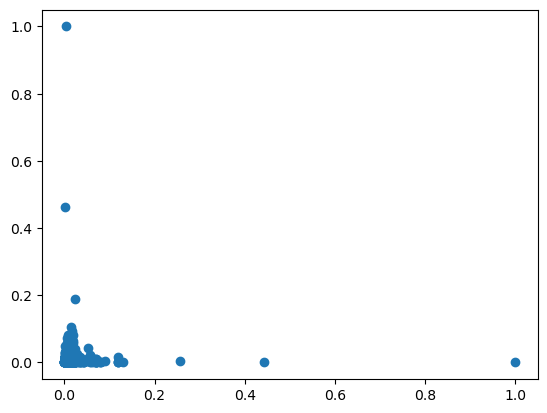

In [336]:
plt.scatter(df2['Area'],df2['Price'])

In [337]:
df2 = df2.groupby('Location').filter(lambda x : len(x)>10)
df2.reset_index()
df2 = df2.reset_index().drop(columns="index",axis=1)


In [338]:
df2.head()

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
0,0.002892,Floor,0.357143,0.4,0.003385,"Al Khaleej, East Riyadh, Riyadh"
1,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
2,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
3,0.001155,Apartment,0.142857,0.2,0.000960,"Al Sakb, Madina"
4,0.002200,Apartment,0.357143,0.4,0.001423,"Al Rabwa, North Jeddah, Jeddah"


In [339]:
df2['Location'].describe()
df2['Area'].shape

(12296,)

In [340]:
cols = scaler.inverse_transform(df2[numeric_cols])
num = pd.DataFrame(cols, columns=numeric_cols)
num.head()

,Price,Area,Number Of Bedrooms,Number Of Bathrooms
0,1249000.0,500.0,6.0,5.0
1,499000.0,154.0,3.0,3.0
2,499000.0,154.0,3.0,3.0
3,499000.0,154.0,3.0,3.0
4,950000.0,220.0,6.0,5.0


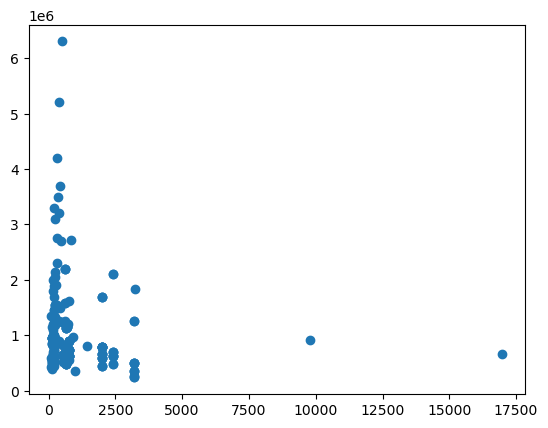

In [341]:
area = num['Area'].to_numpy()
price = num['Price'].to_numpy()
plt.scatter(area[:200],price[:200])

In [342]:
df2['Property Type'].value_counts()

Property Type
Apartment               6490
Villa                   3618
Floor                   2067
Rest House                49
Building                  35
Residential Building      35
Residential Land           2
Name: count, dtype: int64

In [343]:
df2 = df2[~(df2['Property Type'] == 'Residential Land')]


In [344]:
df2['Property Type'].value_counts()

Property Type
Apartment               6490
Villa                   3618
Floor                   2067
Rest House                49
Building                  35
Residential Building      35
Name: count, dtype: int64

In [346]:
df_clean = scaler.inverse_transform(df2[numeric_cols])
df_clean = pd.DataFrame(df_clean,columns=numeric_cols)
df_clean = df_clean.round(3)
df_clean.insert(0,'Property Type',df2['Property Type'],allow_duplicates=True)
df_clean.insert(0,'Location',df2['Location'],allow_duplicates=True)
df_clean.to_csv('bayut_listings_cleaned.csv',index=False)

